**`IMPORT LIBRARIES`**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


**`LOADING DATASET`**

In [ ]:
file_path = "/content/DecodeLabs_Project3_Customer_Segmentation_Dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (1200, 25)


In [ ]:
df.head()

,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchasesPerMonth,AvgTransactionValue,TotalSpend12M,RecencyDays,TenureMonths,WebsiteVisitsPerMonth,AppSessionsPerMonth,DiscountUsageRate,CouponUsageCount,ReturnsRate,LoyaltyPoints,PreferredChannel,CategoryDiversity,AvgItemsPerOrder,WeekendPurchaseRate,TransactionsLast90Days,DaysSinceLastLogin,AvgItemValue,PaymentMethod,SupportTickets
0,CUST_01179,39.86,Female,36809.54,25.20,2.19,48.52,1460.60,47.96,42.44,4.80,2.13,0.97,26,0.10,1167,Store,1.46,2.13,0.38,7,12,21.36,Debit Card,1.67
1,CUST_00866,21.43,Female,23097.20,71.39,6.73,75.67,5041.17,1.00,15.58,15.10,16.36,0.62,56,0.10,3044,Website,5.19,3.08,0.52,21,1,21.94,Digital Wallet,4.03
2,CUST_00102,36.09,Male,NaN,16.30,3.65,139.99,4977.68,29.05,61.13,7.75,6.37,0.13,6,0.03,4373,Store,6.00,2.91,0.45,9,19,49.11,Debit Card,2.01
3,CUST_00440,32.28,Male,71273.50,78.90,8.49,224.69,20440.62,1.00,35.22,17.21,21.18,0.32,33,0.11,21212,Store,9.85,3.34,0.39,21,1,68.70,Credit Card,1.40
4,CUST_00059,37.87,Male,NaN,21.95,2.36,260.51,7501.19,20.73,67.36,8.90,8.60,0.21,6,0.05,6167,Mobile App,5.05,1.79,0.22,6,9,159.21,Credit Card,2.81


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1200 non-null   object 
 1   Age                     1200 non-null   float64
 2   Gender                  1200 non-null   object 
 3   AnnualIncome            1192 non-null   float64
 4   SpendingScore           1200 non-null   float64
 5   PurchasesPerMonth       1200 non-null   float64
 6   AvgTransactionValue     1195 non-null   float64
 7   TotalSpend12M           1200 non-null   float64
 8   RecencyDays             1200 non-null   float64
 9   TenureMonths            1200 non-null   float64
 10  WebsiteVisitsPerMonth   1194 non-null   float64
 11  AppSessionsPerMonth     1200 non-null   float64
 12  DiscountUsageRate       1200 non-null   float64
 13  CouponUsageCount        1200 non-null   int64  
 14  ReturnsRate             1200 non-null   

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,1200,1200,CUST_00956,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1200.00,NaN,NaN,NaN,36.15,9.28,18.00,28.64,35.90,43.40,62.20
Gender,1200,2,Female,653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnnualIncome,1192.00,NaN,NaN,NaN,57419.64,33421.10,12000.00,26251.01,42774.26,88484.87,139084.44
SpendingScore,1200.00,NaN,NaN,NaN,49.99,31.71,1.43,19.16,48.33,81.15,100.00
PurchasesPerMonth,1200.00,NaN,NaN,NaN,5.12,3.17,1.00,2.33,4.11,7.82,14.59
AvgTransactionValue,1195.00,NaN,NaN,NaN,140.26,86.67,18.12,61.58,106.39,213.66,383.13
TotalSpend12M,1200.00,NaN,NaN,NaN,9845.63,10388.80,344.69,2358.93,5785.15,12832.22,47982.13
RecencyDays,1200.00,NaN,NaN,NaN,22.10,16.85,1.00,8.75,16.59,34.99,84.11
TenureMonths,1200.00,NaN,NaN,NaN,43.99,21.76,3.00,27.18,41.88,59.38,107.21


**`CHECKING MISSING VALUES AND DUPLICATES`**

In [ ]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
AnnualIncome,8,0.67
WebsiteVisitsPerMonth,6,0.50
AvgTransactionValue,5,0.42
PreferredChannel,4,0.33
PaymentMethod,4,0.33


In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


**`CLEANING MISSING VALUES`**

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum().sum()

np.int64(0)

**`EXPLORATORY DATA ANALYSIS(EDA)`**

- NUMERICAL FEATURE DISTRIBUTION

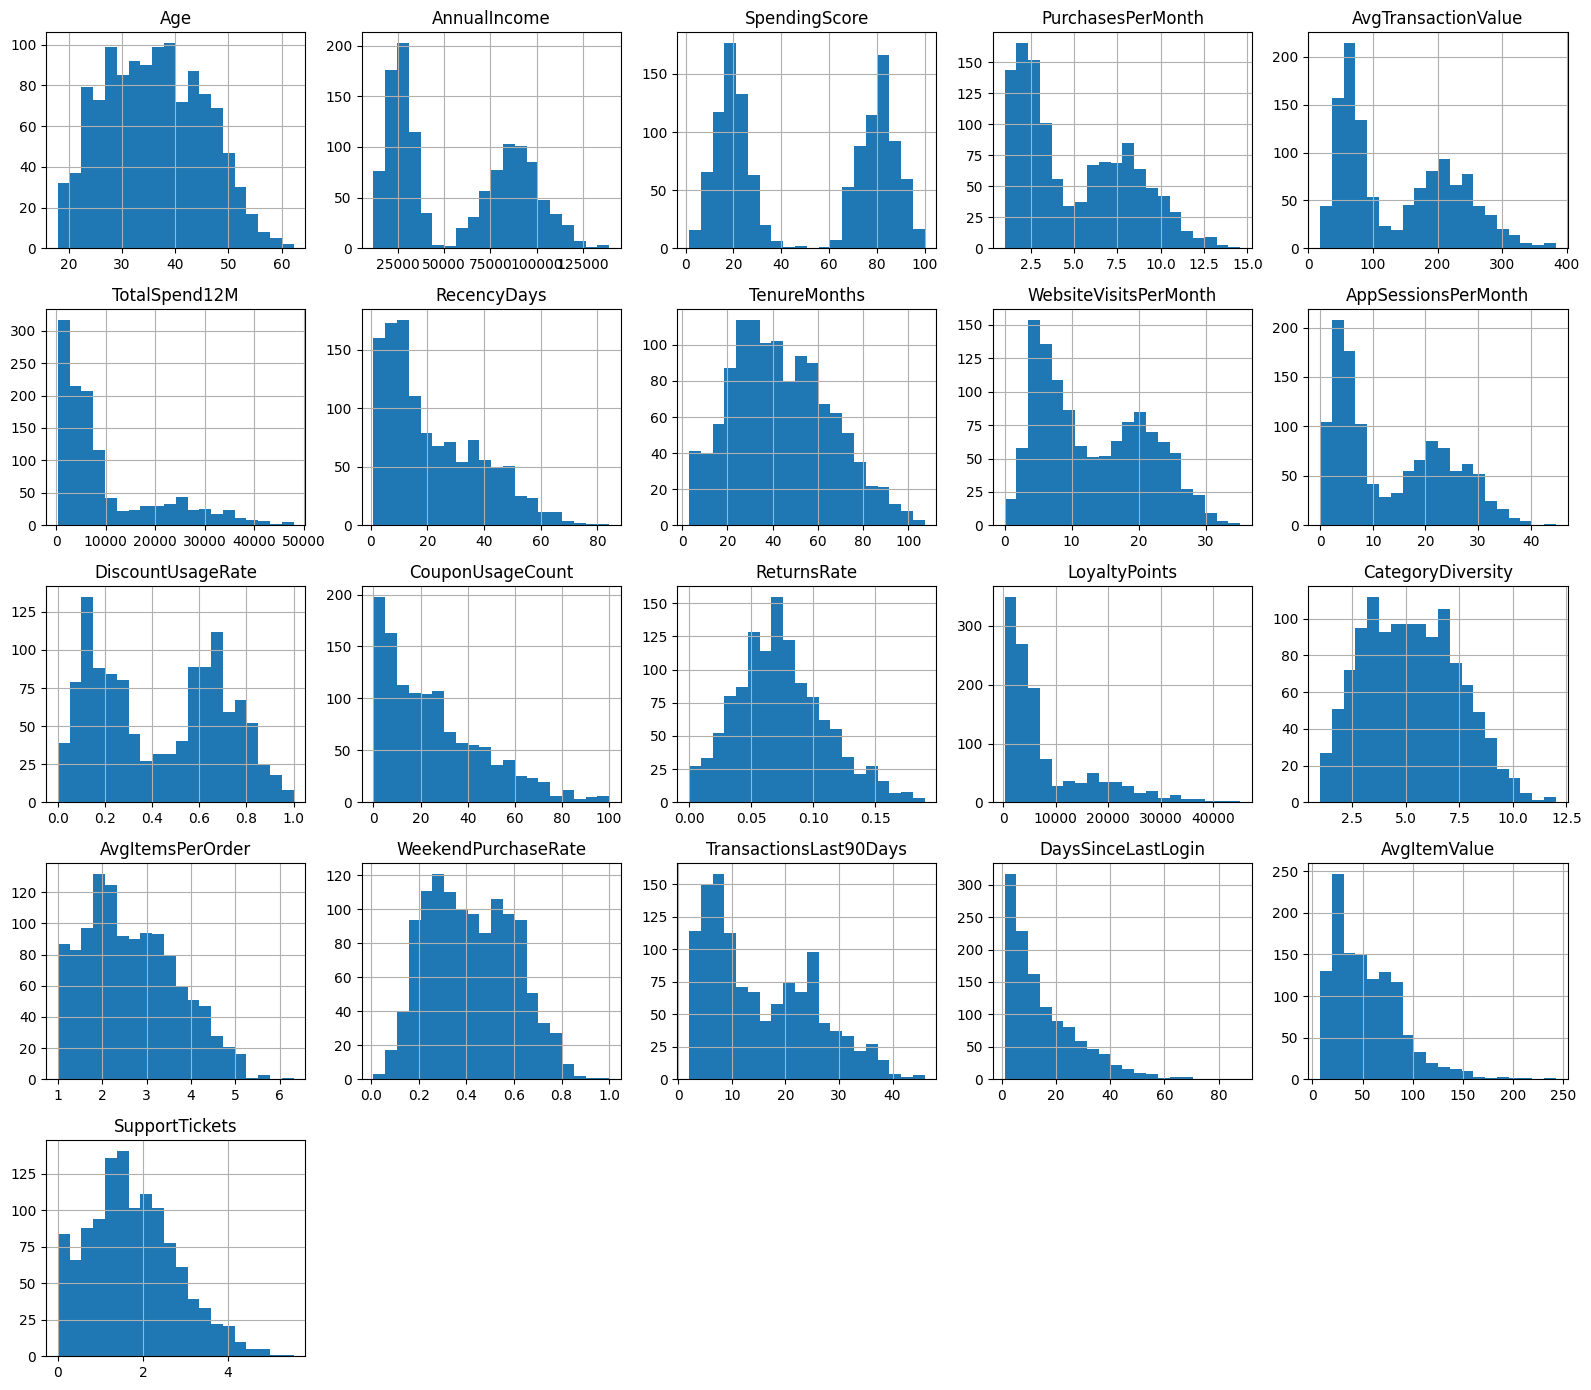

In [ ]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

numeric_features = [
    col for col in numeric_features
    if col != "CustomerID"
]

df[numeric_features] = df[numeric_features].apply(
    pd.to_numeric,
    errors="coerce"
)

df[numeric_features].hist(
    figsize=(16, 14),
    bins=20
)

plt.tight_layout()
plt.show()

- CORRELATION HEATMAP

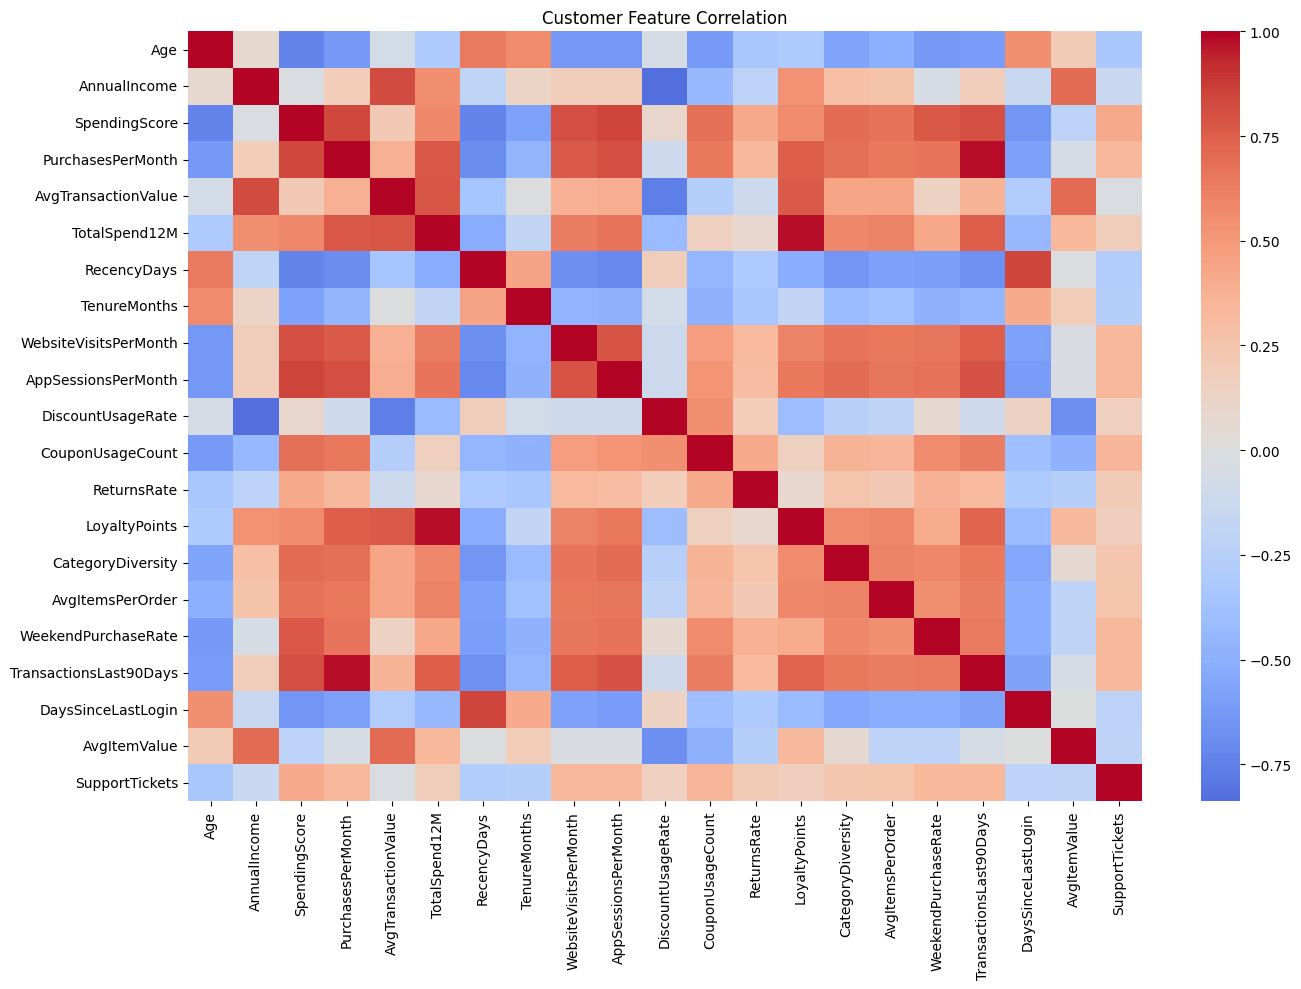

In [ ]:
correlation = df[numeric_features].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Customer Feature Correlation")
plt.tight_layout()
plt.show()

- KEY CUSTOMER BEHAVIOUR VISUALIZATION

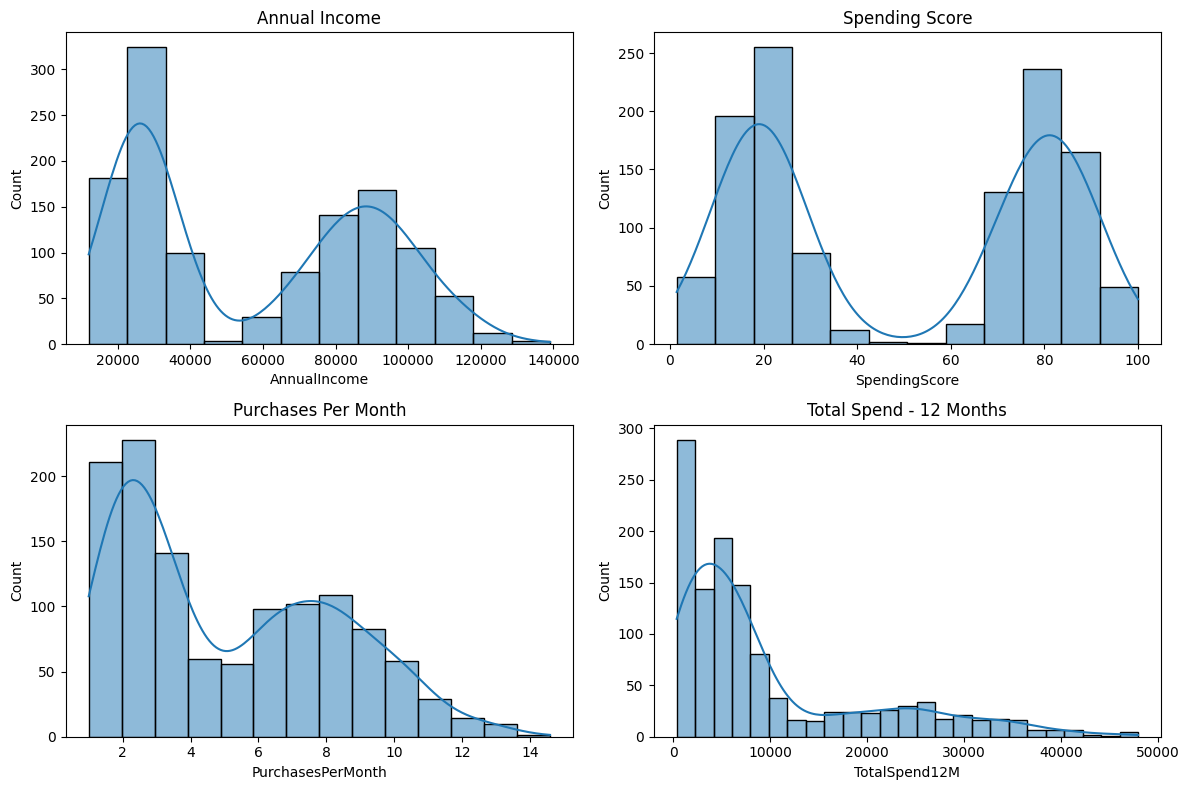

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["AnnualIncome"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Annual Income")

sns.histplot(df["SpendingScore"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Spending Score")

sns.histplot(df["PurchasesPerMonth"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Purchases Per Month")

sns.histplot(df["TotalSpend12M"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Total Spend - 12 Months")

plt.tight_layout()
plt.show()

**`PREPARING FETAURES FOR CLUSTERING`**

In [ ]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'AnnualIncome', 'SpendingScore', 'PurchasesPerMonth', 'AvgTransactionValue', 'TotalSpend12M', 'RecencyDays', 'TenureMonths', 'WebsiteVisitsPerMonth', 'AppSessionsPerMonth', 'DiscountUsageRate', 'CouponUsageCount', 'ReturnsRate', 'LoyaltyPoints', 'PreferredChannel', 'CategoryDiversity', 'AvgItemsPerOrder', 'WeekendPurchaseRate', 'TransactionsLast90Days', 'DaysSinceLastLogin', 'AvgItemValue', 'PaymentMethod', 'SupportTickets']


In [ ]:
print(df.dtypes)

CustomerID                 object
Age                       float64
Gender                     object
AnnualIncome              float64
SpendingScore             float64
PurchasesPerMonth         float64
AvgTransactionValue       float64
TotalSpend12M             float64
RecencyDays               float64
TenureMonths              float64
WebsiteVisitsPerMonth     float64
AppSessionsPerMonth       float64
DiscountUsageRate         float64
CouponUsageCount            int64
ReturnsRate               float64
LoyaltyPoints               int64
PreferredChannel           object
CategoryDiversity         float64
AvgItemsPerOrder          float64
WeekendPurchaseRate       float64
TransactionsLast90Days      int64
DaysSinceLastLogin          int64
AvgItemValue              float64
PaymentMethod              object
SupportTickets            float64
dtype: object


In [ ]:
features = df.drop("CustomerID", axis=1)

In [ ]:
categorical_features = features.select_dtypes(
    include=["object", "category"]
).columns

print(categorical_features.tolist())

['Gender', 'PreferredChannel', 'PaymentMethod']


In [ ]:
features = pd.get_dummies(
    features,
    columns=categorical_features,
    drop_first=True
)

In [ ]:
print("Feature matrix shape:", features.shape)
print("All columns are numerical:", features.select_dtypes(exclude=np.number).shape[1] == 0)

Feature matrix shape: (1200, 27)
All columns are numerical: False


In [ ]:
print(features.select_dtypes(exclude=np.number).columns.tolist())

['Gender_Male', 'PreferredChannel_Store', 'PreferredChannel_Website', 'PaymentMethod_Debit Card', 'PaymentMethod_Digital Wallet', 'PaymentMethod_UPI']


In [ ]:
features = features.astype(float)

In [ ]:
print("Feature matrix shape:", features.shape)
print("All columns are numerical:", features.select_dtypes(exclude=np.number).shape[1] == 0)

Feature matrix shape: (1200, 27)
All columns are numerical: True


**`STANDARDIZATION`**

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features.columns,
    index=features.index
)

X_scaled.head()

,Age,AnnualIncome,SpendingScore,PurchasesPerMonth,AvgTransactionValue,TotalSpend12M,RecencyDays,TenureMonths,WebsiteVisitsPerMonth,AppSessionsPerMonth,DiscountUsageRate,CouponUsageCount,ReturnsRate,LoyaltyPoints,CategoryDiversity,AvgItemsPerOrder,WeekendPurchaseRate,TransactionsLast90Days,DaysSinceLastLogin,AvgItemValue,SupportTickets,Gender_Male,PreferredChannel_Store,PreferredChannel_Website,PaymentMethod_Debit Card,PaymentMethod_Digital Wallet,PaymentMethod_UPI
0,0.40,-0.62,-0.78,-0.93,-1.06,-0.81,1.54,-0.07,-1.07,-1.11,2.00,0.03,0.71,-0.79,-1.74,-0.53,-0.22,-0.85,-0.24,-0.98,-0.09,-0.92,1.64,-0.71,1.71,-0.49,-0.56
1,-1.59,-1.03,0.68,0.51,-0.75,-0.46,-1.25,-1.31,0.23,0.28,0.70,1.44,0.71,-0.57,-0.02,0.39,0.55,0.57,-1.07,-0.96,2.18,-0.92,-0.61,1.40,-0.59,2.04,-0.56
2,-0.01,-0.44,-1.06,-0.46,-0.00,-0.47,0.41,0.79,-0.70,-0.70,-1.13,-0.91,-1.13,-0.41,0.35,0.23,0.17,-0.65,0.28,-0.17,0.24,1.09,1.64,-0.71,1.71,-0.49,-0.56
3,-0.42,0.42,0.91,1.06,0.98,1.02,-1.25,-0.40,0.50,0.75,-0.42,0.36,0.97,1.58,2.13,0.64,-0.17,0.57,-1.07,0.40,-0.35,1.09,1.64,-0.71,-0.59,-0.49,-0.56
4,0.19,-0.44,-0.88,-0.87,1.39,-0.23,-0.08,1.07,-0.55,-0.48,-0.83,-0.91,-0.61,-0.20,-0.08,-0.85,-1.10,-0.95,-0.47,3.05,1.01,1.09,-0.61,-0.71,-0.59,-0.49,-0.56


In [ ]:
X_scaled.describe().T[["mean", "std"]].head(10)

,mean,std
Age,-0.00,1.00
AnnualIncome,0.00,1.00
SpendingScore,0.00,1.00
PurchasesPerMonth,0.00,1.00
AvgTransactionValue,-0.00,1.00
TotalSpend12M,0.00,1.00
RecencyDays,-0.00,1.00
TenureMonths,-0.00,1.00
WebsiteVisitsPerMonth,-0.00,1.00
AppSessionsPerMonth,-0.00,1.00


**`PCA: DIMENSIONALITY REDUCTION`**

In [ ]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.37360345, 0.1657416 , 0.05370026, 0.04907008, 0.04485412,
       0.03930895, 0.03660558, 0.0294875 , 0.02741556, 0.02500282,
       0.02400232, 0.01976465, 0.0169162 , 0.01446088, 0.0130213 ,
       0.01224633, 0.01126507, 0.00968522, 0.00817025, 0.00731815,
       0.00507869, 0.0048948 , 0.00333981, 0.00204506, 0.00166959,
       0.00079716, 0.00053461])

In [ ]:
cumulative_variance = np.cumsum(explained_variance)

variance_df = pd.DataFrame({
    "Component": range(1, len(explained_variance) + 1),
    "Explained_Variance": explained_variance,
    "Cumulative_Variance": cumulative_variance
})

variance_df.head(10)

,Component,Explained_Variance,Cumulative_Variance
0,1,0.37,0.37
1,2,0.17,0.54
2,3,0.05,0.59
3,4,0.05,0.64
4,5,0.04,0.69
5,6,0.04,0.73
6,7,0.04,0.76
7,8,0.03,0.79
8,9,0.03,0.82
9,10,0.03,0.84


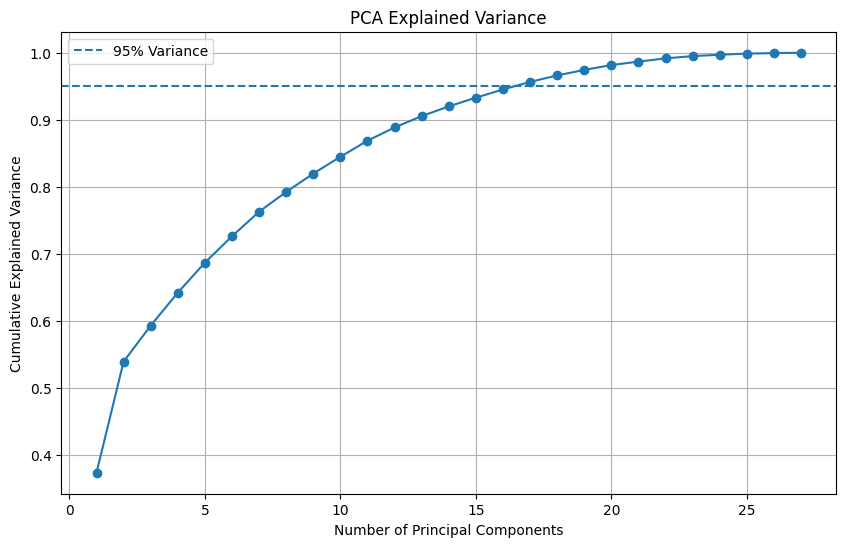

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
variance_df.head(10)

,Component,Explained_Variance,Cumulative_Variance
0,1,0.37,0.37
1,2,0.17,0.54
2,3,0.05,0.59
3,4,0.05,0.64
4,5,0.04,0.69
5,6,0.04,0.73
6,7,0.04,0.76
7,8,0.03,0.79
8,9,0.03,0.82
9,10,0.03,0.84


- FINDING THE 95% THRESHOLD

In [ ]:
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components required for 95% variance:", components_95)
print("Cumulative variance:", cumulative_variance[components_95 - 1])

Components required for 95% variance: 17
Cumulative variance: 0.9564666639751358


- APPLYING PCA WITH 17 COMPONENTS

In [ ]:
pca_final = PCA(n_components=components_95)

X_pca_final = pca_final.fit_transform(X_scaled)

X_pca_final = pd.DataFrame(
    X_pca_final,
    columns=[f"PC{i}" for i in range(1, components_95 + 1)]
)

print("PCA dataset shape:", X_pca_final.shape)

PCA dataset shape: (1200, 17)


In [ ]:
X_pca_final.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
0,-3.17,-2.22,-0.38,-1.61,-1.35,-0.55,-1.24,-0.16,0.66,0.34,0.33,0.76,-0.44,0.85,-0.34,0.21,-0.23
1,2.28,-3.17,0.15,-0.17,2.81,-0.59,-0.24,1.48,0.29,-0.31,0.49,0.74,-0.18,-0.01,-0.61,-0.23,-0.40
2,-1.78,0.82,-0.37,-1.72,-1.63,-0.35,0.78,0.79,-1.04,0.40,0.19,0.40,1.07,-0.12,-0.24,-0.37,-0.79
3,3.22,1.16,-1.67,-0.07,-1.14,-0.35,0.94,-0.73,0.45,0.18,0.40,1.13,0.11,-1.13,1.10,-0.37,0.13
4,-1.62,2.61,0.00,0.27,0.06,-0.56,1.41,1.65,0.76,-1.17,1.10,-1.06,-0.39,-0.49,0.37,0.22,0.63


**`ELBOW METHOD`**

In [ ]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca_final)
    inertia.append(kmeans.inertia_)

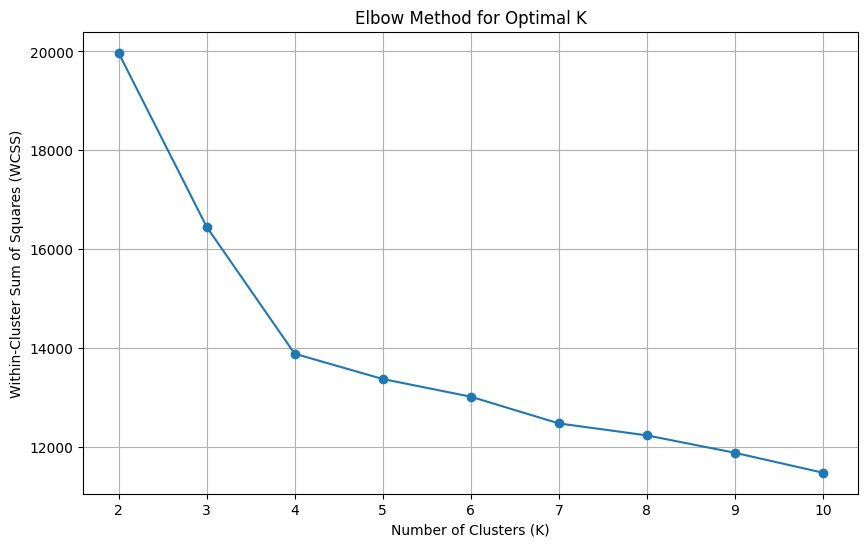

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

**`SILHOUETTE SCORE`**

In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca_final)

    score = silhouette_score(
        X_pca_final,
        labels
    )

    silhouette_scores.append(score)

In [ ]:
silhouette_df = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette_Score": silhouette_scores
})

silhouette_df

,K,Silhouette_Score
0,2,0.32
1,3,0.30
2,4,0.27
3,5,0.24
4,6,0.18
5,7,0.20
6,8,0.16
7,9,0.12
8,10,0.13


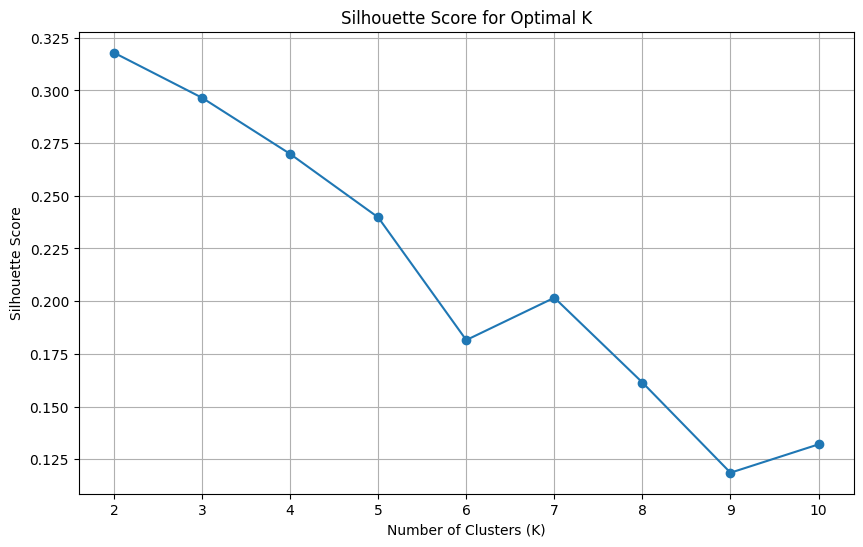

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette_Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [ ]:
silhouette_df.loc[silhouette_df["Silhouette_Score"].idxmax()]

,0
K,2.00
Silhouette_Score,0.32


In [ ]:
silhouette_df

,K,Silhouette_Score
0,2,0.32
1,3,0.30
2,4,0.27
3,5,0.24
4,6,0.18
5,7,0.20
6,8,0.16
7,9,0.12
8,10,0.13


**`SELECTING OPTIMAL`**

In [ ]:
best_k = silhouette_df.loc[
    silhouette_df["Silhouette_Score"].idxmax(),
    "K"
]

best_score = silhouette_df["Silhouette_Score"].max()

print("Best K:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

Best K: 2
Best Silhouette Score: 0.3179


In [ ]:
silhouette_df = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette_Score": silhouette_scores
})

silhouette_df

,K,Silhouette_Score
0,2,0.32
1,3,0.30
2,4,0.27
3,5,0.24
4,6,0.18
5,7,0.20
6,8,0.16
7,9,0.12
8,10,0.13


**`APPLYING FINAL K-MEANS MODEL`**

In [ ]:
kmeans_final = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_pca_final)

In [ ]:
df["Cluster"] = cluster_labels

df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,600
1,600


**`CLUSTER PROFILING`**

In [ ]:
cluster_profile = df.groupby("Cluster").agg({
    "Age": "mean",
    "AnnualIncome": "mean",
    "SpendingScore": "mean",
    "PurchasesPerMonth": "mean",
    "AvgTransactionValue": "mean",
    "TotalSpend12M": "mean",
    "RecencyDays": "mean",
    "WebsiteVisitsPerMonth": "mean",
    "AppSessionsPerMonth": "mean",
    "DiscountUsageRate": "mean",
    "ReturnsRate": "mean",
    "LoyaltyPoints": "mean",
    "CategoryDiversity": "mean",
    "AvgItemsPerOrder": "mean"
}).round(2)

cluster_profile

,Age,AnnualIncome,SpendingScore,PurchasesPerMonth,AvgTransactionValue,TotalSpend12M,RecencyDays,WebsiteVisitsPerMonth,AppSessionsPerMonth,DiscountUsageRate,ReturnsRate,LoyaltyPoints,CategoryDiversity,AvgItemsPerOrder
Cluster,,,,,,,,,,,,,,
0,43.30,58092.13,19.17,2.40,120.74,3780.76,35.05,6.56,4.61,0.41,0.06,3006.66,3.67,1.96
1,29.00,56551.88,80.81,7.85,159.50,15910.49,9.15,19.97,22.43,0.45,0.09,12650.91,6.80,3.40


**`VISUALIZING CUSTOMER CLUSTER`**

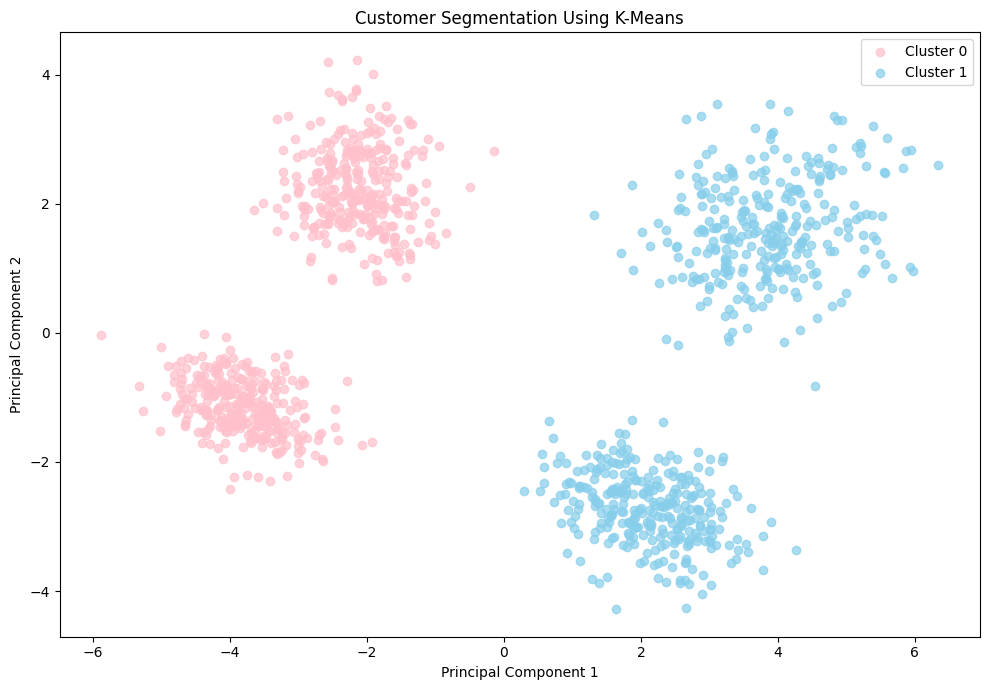

In [ ]:
plt.figure(figsize=(10, 7))

colors = ["pink", "skyblue"]

for cluster in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cluster

    plt.scatter(
        X_pca_final.loc[mask, "PC1"],
        X_pca_final.loc[mask, "PC2"],
        color=colors[cluster],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation Using K-Means")
plt.legend()

plt.tight_layout()
plt.show()

**`3-D PCA VISUALIZATION`**

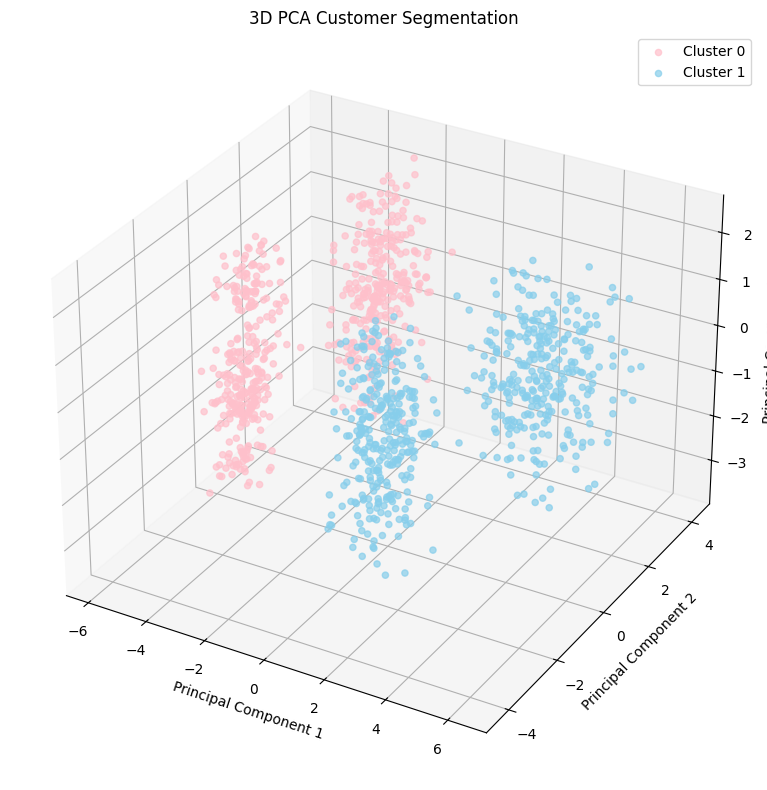

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

colors = ["pink", "skyblue"]

for cluster in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cluster

    ax.scatter(
        X_pca_final.loc[mask, "PC1"],
        X_pca_final.loc[mask, "PC2"],
        X_pca_final.loc[mask, "PC3"],
        color=colors[cluster],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Customer Segmentation")
ax.legend()

plt.tight_layout()
plt.show()

**`CREATING CUSTOMER PERSONAS`**

In [ ]:
id="f3x7ab"
cluster_profile.T

Cluster,0,1
Age,43.30,29.00
AnnualIncome,58092.13,56551.88
SpendingScore,19.17,80.81
PurchasesPerMonth,2.40,7.85
AvgTransactionValue,120.74,159.50
TotalSpend12M,3780.76,15910.49
RecencyDays,35.05,9.15
WebsiteVisitsPerMonth,6.56,19.97
AppSessionsPerMonth,4.61,22.43
DiscountUsageRate,0.41,0.45


In [ ]:
cluster_profile.T

Cluster,0,1
Age,43.30,29.00
AnnualIncome,58092.13,56551.88
SpendingScore,19.17,80.81
PurchasesPerMonth,2.40,7.85
AvgTransactionValue,120.74,159.50
TotalSpend12M,3780.76,15910.49
RecencyDays,35.05,9.15
WebsiteVisitsPerMonth,6.56,19.97
AppSessionsPerMonth,4.61,22.43
DiscountUsageRate,0.41,0.45


**`GENERATING PERSONA SUMMARY`**

In [ ]:
persona_summary = cluster_profile[
    [
        "AnnualIncome",
        "SpendingScore",
        "PurchasesPerMonth",
        "TotalSpend12M",
        "RecencyDays",
        "DiscountUsageRate",
        "LoyaltyPoints"
    ]
].copy()

persona_summary

,AnnualIncome,SpendingScore,PurchasesPerMonth,TotalSpend12M,RecencyDays,DiscountUsageRate,LoyaltyPoints
Cluster,,,,,,,
0,58092.13,19.17,2.40,3780.76,35.05,0.41,3006.66
1,56551.88,80.81,7.85,15910.49,9.15,0.45,12650.91


**`CREATING PERSONA MAPPING`**

In [ ]:
persona_mapping = {
    0: "Affluent Conservatives",
    1: "High-Value Trendsetters",
    2: "Budget Explorers",
    3: "Conservative Minimizers"
}

df["Persona"] = df["Cluster"].map(persona_mapping)

df[["Cluster", "Persona"]].drop_duplicates().sort_values("Cluster")

,Cluster,Persona
0,0,Affluent Conservatives
1,1,High-Value Trendsetters


**`PERSONA-WISE BUSINESS ANALYSIS `**

In [ ]:
persona_analysis = cluster_profile.copy()

persona_analysis["Persona"] = persona_analysis.index.map(persona_mapping)

persona_analysis = persona_analysis[
    [
        "Persona",
        "AnnualIncome",
        "SpendingScore",
        "PurchasesPerMonth",
        "TotalSpend12M",
        "RecencyDays",
        "DiscountUsageRate",
        "LoyaltyPoints"
    ]
]

persona_analysis

,Persona,AnnualIncome,SpendingScore,PurchasesPerMonth,TotalSpend12M,RecencyDays,DiscountUsageRate,LoyaltyPoints
Cluster,,,,,,,,
0,Affluent Conservatives,58092.13,19.17,2.40,3780.76,35.05,0.41,3006.66
1,High-Value Trendsetters,56551.88,80.81,7.85,15910.49,9.15,0.45,12650.91


**`BUSINESS RECOMMENDATIONS`**

In [ ]:
persona_recommendations = {
    "Affluent Conservatives": "Focus on premium products, loyalty benefits, and personalized recommendations to increase retention and lifetime value.",
    "High-Value Trendsetters": "Promote new launches, premium products, early-access offers, and personalized campaigns to maximize spending.",
    "Budget Explorers": "Use discounts, bundles, coupons, and cross-selling offers to encourage repeat purchases and increase order value.",
    "Conservative Minimizers": "Use targeted discounts, affordable bundles, and re-engagement campaigns to improve purchase frequency."
}

persona_strategy = pd.DataFrame({
    "Persona": list(persona_recommendations.keys()),
    "Business_Strategy": list(persona_recommendations.values())
})

persona_strategy

,Persona,Business_Strategy
0,Affluent Conservatives,"Focus on premium products, loyalty benefits, a..."
1,High-Value Trendsetters,"Promote new launches, premium products, early-..."
2,Budget Explorers,"Use discounts, bundles, coupons, and cross-sel..."
3,Conservative Minimizers,"Use targeted discounts, affordable bundles, an..."


**`FINAL SEGMENTATIONS DATASET`**

In [ ]:
final_segmentation = df[
    ["CustomerID", "Cluster", "Persona"]
].copy()

final_segmentation.head()

,CustomerID,Cluster,Persona
0,CUST_01179,0,Affluent Conservatives
1,CUST_00866,1,High-Value Trendsetters
2,CUST_00102,0,Affluent Conservatives
3,CUST_00440,1,High-Value Trendsetters
4,CUST_00059,0,Affluent Conservatives


In [ ]:
final_segmentation["Persona"].value_counts()

,count
Persona,
Affluent Conservatives,600
High-Value Trendsetters,600


**`CREATING CLUSTER SIZE VISUALIZATION`**

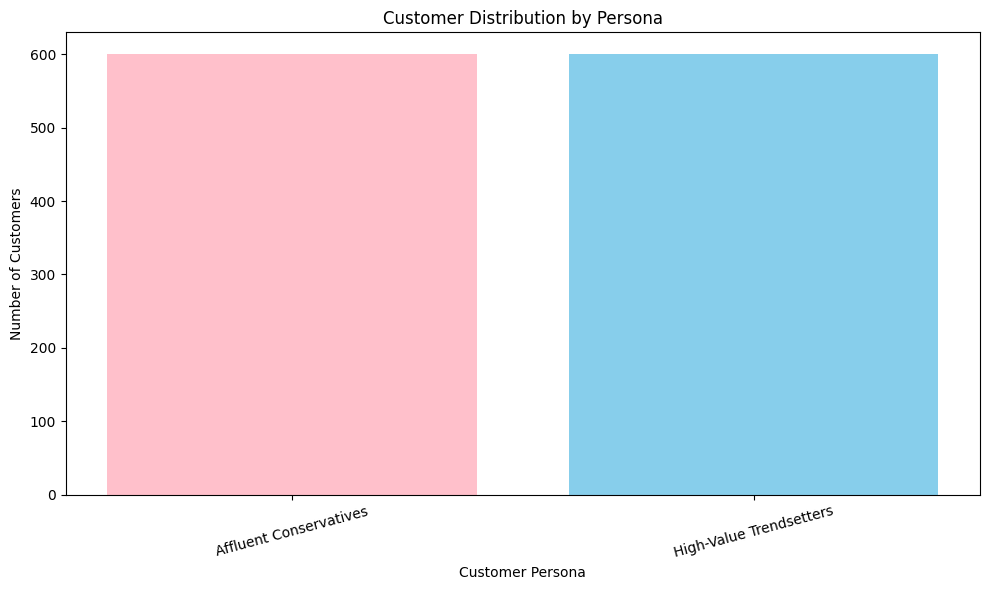

In [ ]:
cluster_counts = df["Persona"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    cluster_counts.index,
    cluster_counts.values,
    color=["pink", "skyblue", "pink", "skyblue"]
)

plt.xlabel("Customer Persona")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Persona")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**`PERSONA COMPARISON`**

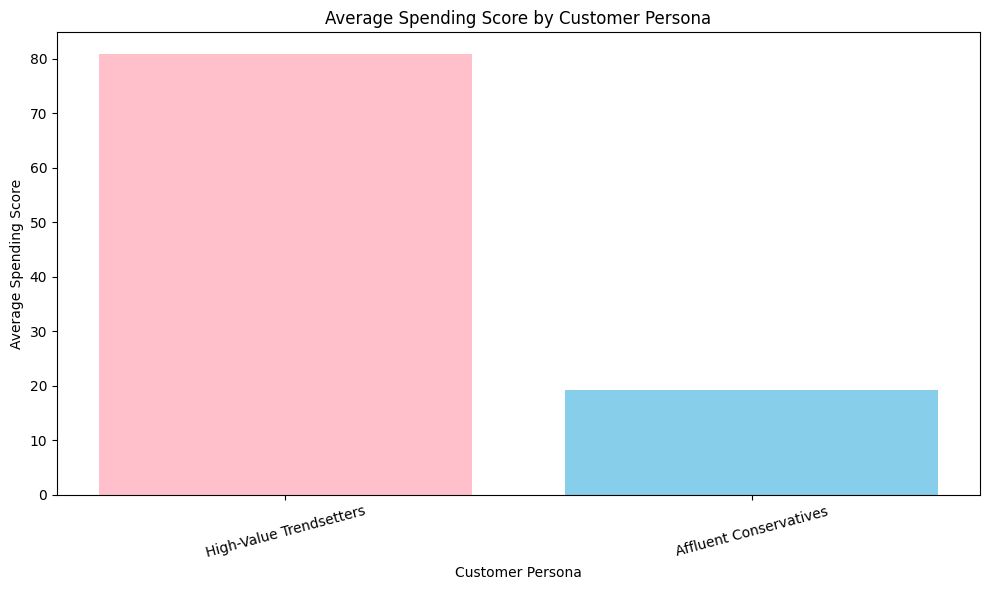

In [ ]:
persona_spending = df.groupby("Persona")["SpendingScore"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    persona_spending.index,
    persona_spending.values,
    color=["pink", "skyblue", "pink", "skyblue"]
)

plt.xlabel("Customer Persona")
plt.ylabel("Average Spending Score")
plt.title("Average Spending Score by Customer Persona")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**`COMPARING TOTAL CUSTOMER VALUE`**

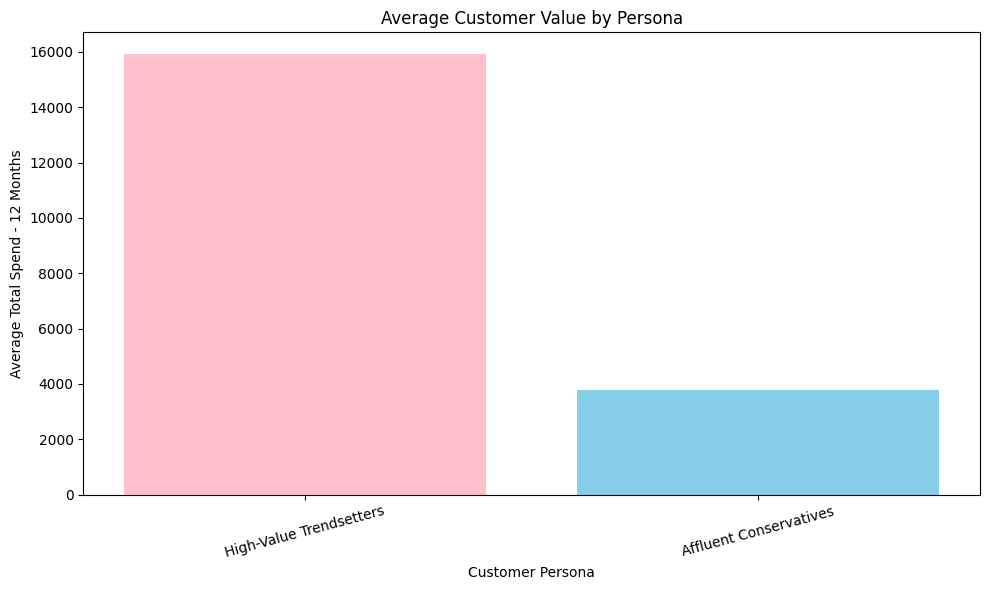

In [ ]:
persona_spend = (
    df.groupby("Persona")["TotalSpend12M"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    persona_spend.index,
    persona_spend.values,
    color=["pink", "skyblue", "pink", "skyblue"]
)

plt.xlabel("Customer Persona")
plt.ylabel("Average Total Spend - 12 Months")
plt.title("Average Customer Value by Persona")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**`COMPARING PURCHASE FREQUENCY`**

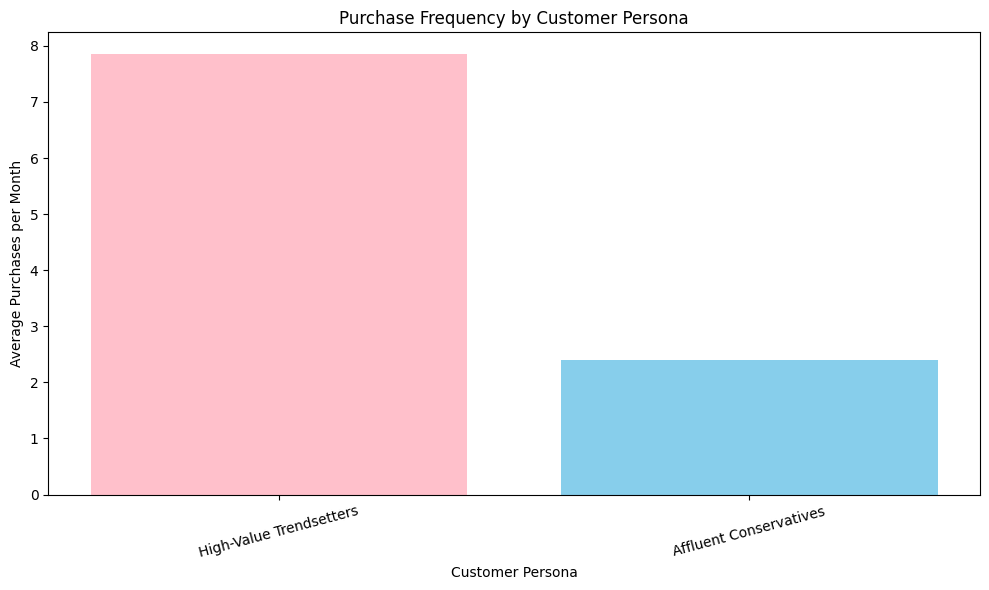

In [ ]:
persona_frequency = (
    df.groupby("Persona")["PurchasesPerMonth"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    persona_frequency.index,
    persona_frequency.values,
    color=["pink", "skyblue", "pink", "skyblue"]
)

plt.xlabel("Customer Persona")
plt.ylabel("Average Purchases per Month")
plt.title("Purchase Frequency by Customer Persona")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**`FINAL PERSONA SUMMARY`**

In [ ]:
final_persona_summary = df.groupby("Persona").agg(
    Customers=("CustomerID", "count"),
    Avg_Income=("AnnualIncome", "mean"),
    Avg_Spending_Score=("SpendingScore", "mean"),
    Avg_Purchases_Per_Month=("PurchasesPerMonth", "mean"),
    Avg_Total_Spend_12M=("TotalSpend12M", "mean"),
    Avg_Recency_Days=("RecencyDays", "mean"),
    Avg_Loyalty_Points=("LoyaltyPoints", "mean")
).round(2)

final_persona_summary

,Customers,Avg_Income,Avg_Spending_Score,Avg_Purchases_Per_Month,Avg_Total_Spend_12M,Avg_Recency_Days,Avg_Loyalty_Points
Persona,,,,,,,
Affluent Conservatives,600,58092.13,19.17,2.40,3780.76,35.05,3006.66
High-Value Trendsetters,600,56551.88,80.81,7.85,15910.49,9.15,12650.91


**`IDENTIFYING BEST AND WEAKEST SEGMENTS`**

In [ ]:
best_segment = final_persona_summary["Avg_Total_Spend_12M"].idxmax()
weakest_segment = final_persona_summary["Avg_Total_Spend_12M"].idxmin()

highest_frequency = final_persona_summary["Avg_Purchases_Per_Month"].idxmax()
highest_spending = final_persona_summary["Avg_Spending_Score"].idxmax()

print("Highest Value Segment:", best_segment)
print("Lowest Value Segment:", weakest_segment)
print("Most Frequent Buyers:", highest_frequency)
print("Highest Spending Behavior:", highest_spending)

Highest Value Segment: High-Value Trendsetters
Lowest Value Segment: Affluent Conservatives
Most Frequent Buyers: High-Value Trendsetters
Highest Spending Behavior: High-Value Trendsetters


**`FINAL BUSINESS INSIGHTS`**

In [ ]:
print("CUSTOMER SEGMENTATION INSIGHTS")
print("-" * 40)

print(f"Highest Value Segment: {best_segment}")
print(f"Lowest Value Segment: {weakest_segment}")
print(f"Most Frequent Buyers: {highest_frequency}")
print(f"Highest Spending Behavior: {highest_spending}")

CUSTOMER SEGMENTATION INSIGHTS
----------------------------------------
Highest Value Segment: High-Value Trendsetters
Lowest Value Segment: Affluent Conservatives
Most Frequent Buyers: High-Value Trendsetters
Highest Spending Behavior: High-Value Trendsetters


In [ ]:
final_persona_summary.sort_values(
    "Avg_Total_Spend_12M",
    ascending=False
)

,Customers,Avg_Income,Avg_Spending_Score,Avg_Purchases_Per_Month,Avg_Total_Spend_12M,Avg_Recency_Days,Avg_Loyalty_Points
Persona,,,,,,,
High-Value Trendsetters,600,56551.88,80.81,7.85,15910.49,9.15,12650.91
Affluent Conservatives,600,58092.13,19.17,2.40,3780.76,35.05,3006.66


**`EXPORTING FINAL RESULTS`**

In [ ]:
id="x8p4km"
final_segmentation.to_csv(
    "Project3_Final_Customer_Segmentation.csv",
    index=False
)

final_persona_summary.to_csv(
    "Project3_Persona_Summary.csv"
)

print("Final datasets exported successfully.")

Final datasets exported successfully.
